<a href="https://colab.research.google.com/github/thiagopereiramagalhaes/Classificacao_de_Perfis_de_Turistas-Uma_Analise_Comparativa_com_k-NN_e_Random_Forest/blob/main/Classifica%C3%A7%C3%A3o_de_Perfis_de_Turistas_por_Comunica%C3%A7%C3%A3o_N%C3%A3o_Verbal_Uma_An%C3%A1lise_Comparativa_com_k_NN_e_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classificação de Perfis de Turistas por Comunicação Não-Verbal: Uma Análise Comparativa com k-NN e Random Forest

###Imports

Nessa seção iremos importar as bibliotecas necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

###Carregar a base de dados

Abaixo iremos carregar a base de dados "Non verbal tourists data DataSet".
Disponível em: https://archive.ics.uci.edu/ml/machine-learning-databases/00620/non-verbal%20tourist%20data.csv

**Additional Information**

A total of 73 customers, aged between 24 and 81 years old, were surveyed. Of the customers surveyed, 38 were returning customers, and 35 were new cus-tomers. The variables chosen are the essential ones that make up the non-verbal communication system. In addition to being the most feasible to evaluate in clients. The non-verbal system is made up of subsystems such as kinesic, paralanguage, proxemic, chronic, and others. In the design of the questionnaire, the indicators that make up these subsystems were taken into account to be explored as part of the client's communication preferences, as well as being feasible to evaluate in clients. The 22 variables analyzed were considered feasible to evaluate by the hotel's clientele.

**Has Missing Values?**

No

Obs: iremos considerar a variável de saída: **Tipo/classe do cliente**

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00620/non-verbal%20tourist%20data.csv"
df = pd.read_csv(url)

In [ ]:
df

,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,F,42,uruguay,no,likes,indiferent,indiferent,likes,likes,indiferent,...,8,3,C,dislikes,dislikes,indiferent,dislikes,dislikes,dislikes,0
1,M,60,brasil,no,likes,indiferent,indiferent,likes,likes,likes,...,9,1,B,dislikes,dislikes,likes,likes,dislikes,dislikes,0
2,F,25,england,no,indiferent,indiferent,indiferent,likes,likes,indiferent,...,10,5,C,dislikes,dislikes,likes,dislikes,dislikes,dislikes,0
3,M,43,canada,no,likes,dislikes,dislikes,likes,likes,indiferent,...,2,1,C,dislikes,dislikes,likes,dislikes,indiferent,dislikes,0
4,M,30,hungary,no,indiferent,indiferent,indiferent,likes,likes,indiferent,...,9,3,C,dislikes,dislikes,likes,indiferent,dislikes,dislikes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,F,36,england,no,indiferent,dislikes,dislikes,likes,likes,dislikes,...,7,4,C,dislikes,dislikes,likes,dislikes,dislikes,dislikes,4
69,M,38,russia,no,dislikes,dislikes,dislikes,likes,likes,dislikes,...,2,5,C,dislikes,dislikes,dislikes,dislikes,dislikes,dislikes,5
70,F,46,canada,no,dislikes,indiferent,indiferent,indiferent,likes,dislikes,...,1,2,A,dislikes,dislikes,indiferent,indiferent,dislikes,indiferent,5
71,M,39,germany,no,dislikes,dislikes,?,likes,likes,dislikes,...,4,4,C,dislikes,dislikes,indiferent,dislikes,dislikes,dislikes,5


###Tratamento dos dados

Abaixo trate os valores "?" presente em algumas colunas. Use a estratégia que for mais confortável.

Dica: Use a função `replace`.

In [ ]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

len(df)

69

A seguir substitua os valores categóricos (
Male, Female, Indifferent, likes, dislikes) por valores numéricos definidos por você.

Dica: leia a [página](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html) da documentação da biblioteca Pandas.


In [ ]:
mapping = {
    'Male': 0, 'Female': 1, 'M': 0, 'F': 1,
    'Indifferent': 0, 'indiferent': 0, 'likes': 1, 'dislikes': -1,
    'yes': 1, 'no': 0
}
for col in df.select_dtypes(include=['object']).columns:
    if col != target_col:
        df[col] = df[col].map(mapping).fillna(df[col])

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

df = df.apply(pd.to_numeric)
df.head()

,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,1,42,14,0,1,0,0,1,1,0,...,8,3,2,-1,-1,0,-1,-1,-1,0
2,1,25,5,0,0,0,0,1,1,0,...,1,5,2,-1,-1,1,-1,-1,-1,0
3,0,43,1,0,1,-1,-1,1,1,0,...,2,1,2,-1,-1,1,-1,0,-1,0
4,0,30,7,0,0,0,0,1,1,0,...,9,3,2,-1,-1,1,0,-1,-1,0
5,1,31,1,1,1,1,1,1,1,1,...,9,1,1,0,-1,1,0,-1,-1,1


Visualize os dados usando das funções que achar necessarias e caso necessario remova as colunas que não agreguem informação. Pode utilizar a matriz de correlação para selecionar ou remover features. Justifique a remoção de colunas caso ocoram.

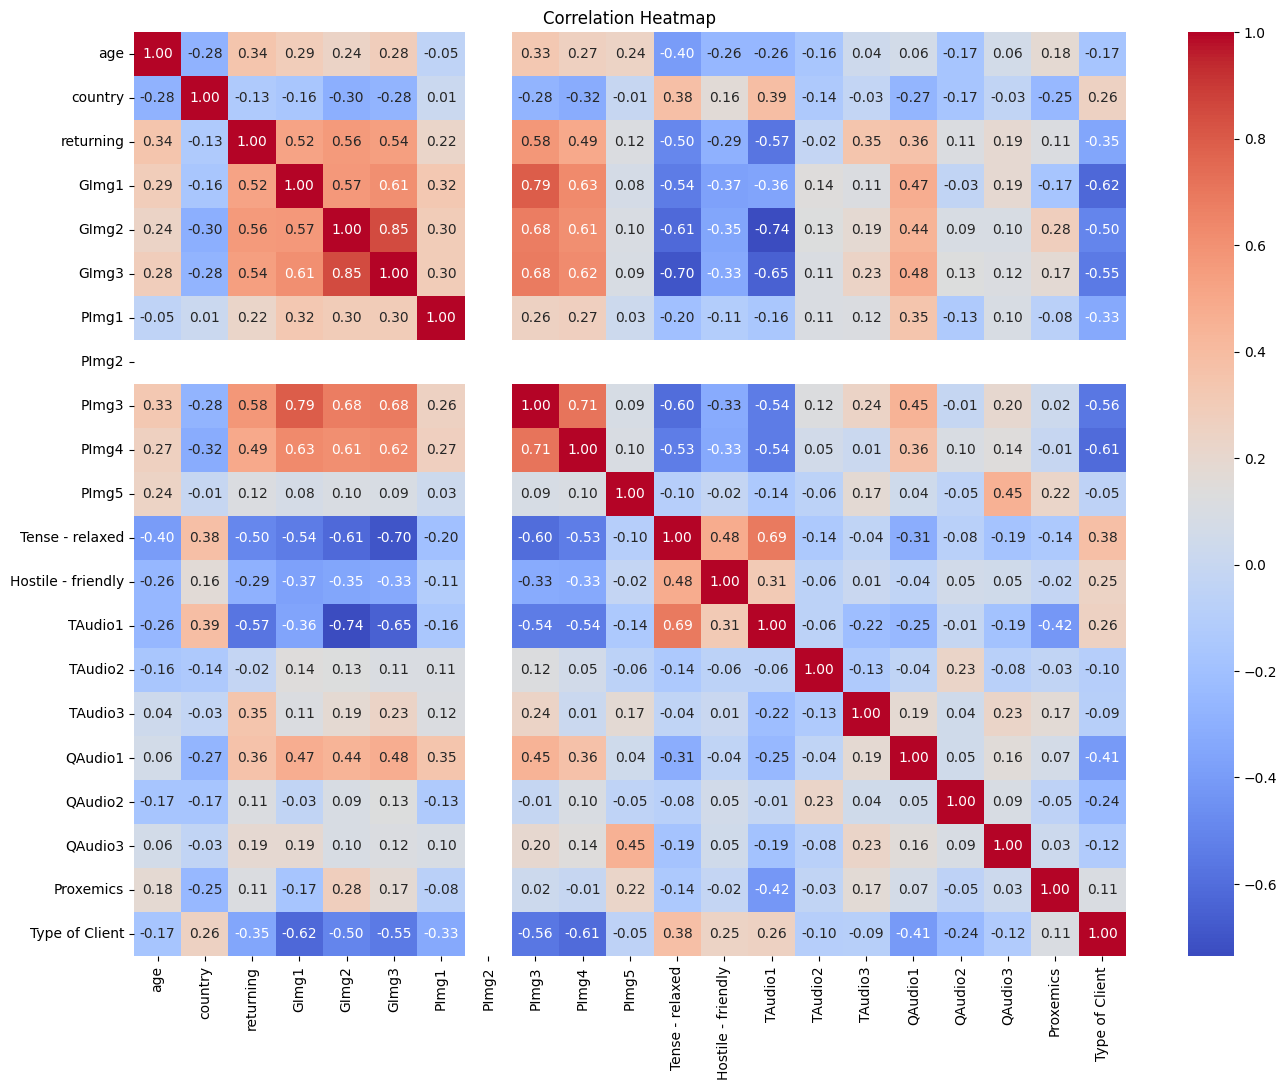

Colunas removidas devido à correlação próxima de zero. (< 0.05): []


In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr = df.corr()[target_col].abs()
threshold = 0.05
cols_to_drop = corr[corr < threshold].index.tolist()
print(f"Colunas removidas devido à correlação próxima de zero. (< {threshold}): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

Faça as demais transformações que julgar necessárias na base de dados.

In [ ]:
scaler = StandardScaler()
X_cols = [c for c in df.columns if c != target_col]
df[X_cols] = scaler.fit_transform(df[X_cols])

###Separação treino/teste

Separe os valores e os rótulos da base de dados.

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

Separe a base de dados em teste e treino. Use a divisão 75% para treino 25% para teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (51, 20), X_test shape: (18, 20)


### k-NN

Instancie e treine a k-NN com diversos valores para os vizinhos. Durante o fim do treino calcule metricas que julgue que venham a agregar com o problema e justifique porque usou elas.

In [ ]:
knn_initial = KNeighborsClassifier()
knn_initial.fit(X_train, y_train)
y_pred_knn_init = knn_initial.predict(X_test)

Plote a matriz de confusão.

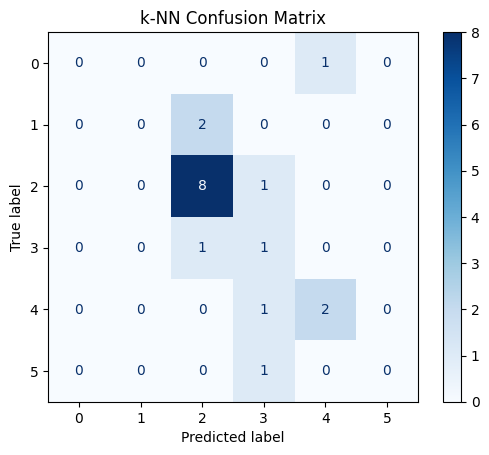

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(knn_initial, X_test, y_test, cmap='Blues')
plt.title("k-NN Confusion Matrix")
plt.show()

Exiba as métricas do classification report.

In [ ]:
print(classification_report(y_test, y_pred_knn_init))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.73      0.89      0.80         9
           3       0.25      0.50      0.33         2
           4       0.67      0.67      0.67         3
           5       0.00      0.00      0.00         1

    accuracy                           0.61        18
   macro avg       0.27      0.34      0.30        18
weighted avg       0.50      0.61      0.55        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Otimizar o valor de K
- Ache o melhor valor de k para o algoritmo k-NN. Utilize o intervalo de 1 a 30.

In [ ]:
k_values = range(1, 31)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_values[np.argmax(k_scores)]
print(f"K value: {best_k}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

K value: 4


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Exiba a média dos resultados obtidos do experimento anterior

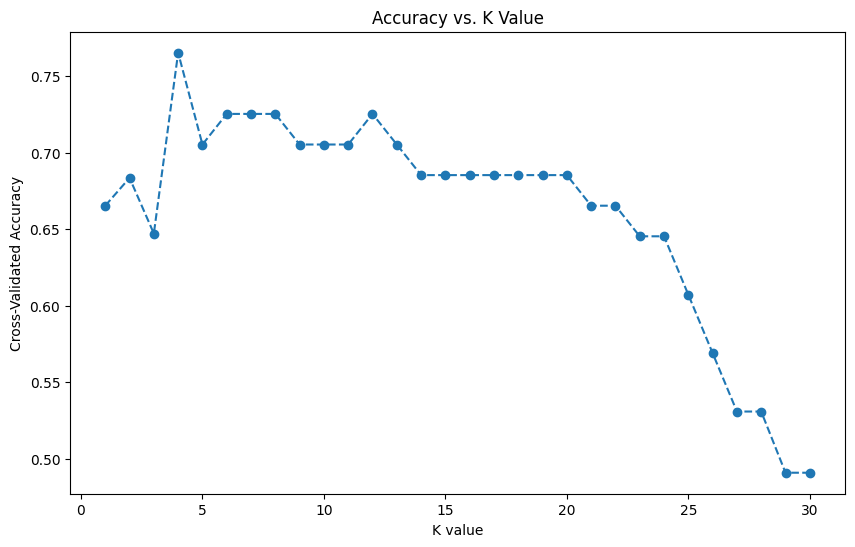

K=1: mean accuracy = 0.6655
K=2: mean accuracy = 0.6836
K=3: mean accuracy = 0.6473
K=4: mean accuracy = 0.7655
K=5: mean accuracy = 0.7055
K=6: mean accuracy = 0.7255
K=7: mean accuracy = 0.7255
K=8: mean accuracy = 0.7255
K=9: mean accuracy = 0.7055
K=10: mean accuracy = 0.7055
K=11: mean accuracy = 0.7055
K=12: mean accuracy = 0.7255
K=13: mean accuracy = 0.7055
K=14: mean accuracy = 0.6855
K=15: mean accuracy = 0.6855
K=16: mean accuracy = 0.6855
K=17: mean accuracy = 0.6855
K=18: mean accuracy = 0.6855
K=19: mean accuracy = 0.6855
K=20: mean accuracy = 0.6855
K=21: mean accuracy = 0.6655
K=22: mean accuracy = 0.6655
K=23: mean accuracy = 0.6455
K=24: mean accuracy = 0.6455
K=25: mean accuracy = 0.6073
K=26: mean accuracy = 0.5691
K=27: mean accuracy = 0.5309
K=28: mean accuracy = 0.5309
K=29: mean accuracy = 0.4909
K=30: mean accuracy = 0.4909


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o', linestyle='dashed')
plt.xlabel('K value')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Accuracy vs. K Value')
plt.show()

for k, score in zip(k_values, k_scores):
    print(f"K={k}: mean accuracy = {score:.4f}")

Treine um modelo de k-NN com o melhor valor de k obtido e:

1. Plot a matriz de confusão
2. Exiba as métricas do Classification Report para o modelo k-NN


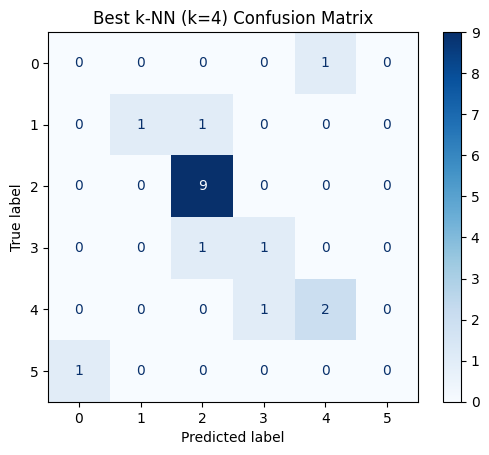

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)

disp = ConfusionMatrixDisplay.from_estimator(knn_best, X_test, y_test, cmap='Blues')
plt.title(f"Best k-NN (k={best_k}) Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_knn_best))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.50      0.67         2
           2       0.82      1.00      0.90         9
           3       0.50      0.50      0.50         2
           4       0.67      0.67      0.67         3
           5       0.00      0.00      0.00         1

    accuracy                           0.72        18
   macro avg       0.50      0.44      0.46        18
weighted avg       0.69      0.72      0.69        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Random Forest

Instancie e treine a Random Forest com os parâmetros default do algoritmo. Durante o fim do treino calcule metricas que julgue que venham a agregar com o problema e justifique porque usou elas.

In [ ]:
rf_initial = RandomForestClassifier(random_state=42)
rf_initial.fit(X_train, y_train)
y_pred_rf_init = rf_initial.predict(X_test)

Exiba as métricas do Classification Report para o modelo Random Forest

In [ ]:
print(classification_report(y_test, y_pred_rf_init))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.80      0.89      0.84         9
           3       0.40      1.00      0.57         2
           4       0.67      0.67      0.67         3
           5       0.00      0.00      0.00         1

    accuracy                           0.67        18
   macro avg       0.31      0.43      0.35        18
weighted avg       0.56      0.67      0.60        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plote a matriz de confusão.

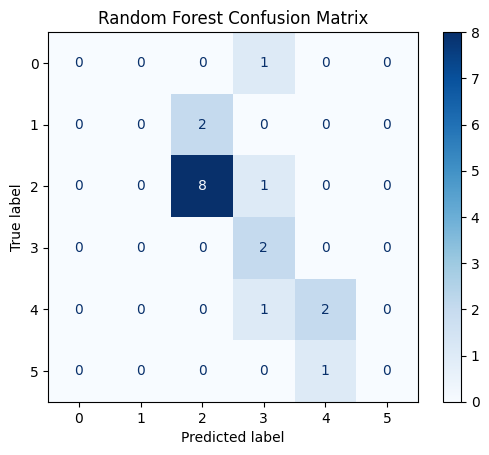

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(rf_initial, X_test, y_test, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

## Grid Search

Faça um grid search dos parâmetros da **Random Forest**:
1. n_estimators = number of trees in the foreset
2. max_features = max number of features considered for splitting a node
3. max_depth = max number of levels in each decision tree
4. min_samples_split = min number of data points placed in a node before the node is split
4. min_samples_leaf = min number of data points allowed in a leaf node
6. bootstrap = method for sampling data points (with or without replacement)

Links de referência:
1. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
2. https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=param_grid,
                       cv=3, n_jobs=-1, verbose=1, scoring='accuracy')
rf_grid.fit(X_train, y_train)
best_params = rf_grid.best_params_
print(f"Best parameters: {best_params}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Exiba a média dos resultados obtidos do experimento anterior

In [ ]:
print(f"Best cross-validation accuracy: {rf_grid.best_score_:.4f}")

Best cross-validation accuracy: 0.8627


Treine um modelo de Random Forest com os melhores valores dos parâmetros obtidos:

1. Exiba as métricas do Classification Report
2. Plot a matriz de confusão

In [ ]:
rf_best = rf_grid.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)

print("Best Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_best))

Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.80      0.89      0.84         9
           3       0.40      1.00      0.57         2
           4       0.67      0.67      0.67         3
           5       0.00      0.00      0.00         1

    accuracy                           0.67        18
   macro avg       0.31      0.43      0.35        18
weighted avg       0.56      0.67      0.60        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


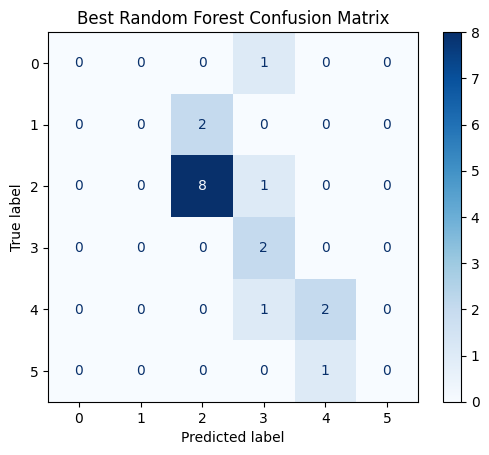

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test, cmap='Blues')
plt.title("Best Random Forest Confusion Matrix")
plt.show()

## Conclusão

In [ ]:
acc_knn = accuracy_score(y_test, y_pred_knn_best)
acc_rf = accuracy_score(y_test, y_pred_rf_best)

print(f"Acurácia do modelo k-NN otimizado (k={best_k}): {acc_knn:.4f}")
print(f"Acurácia do modelo Random Forest otimizado: {acc_rf:.4f}")
if acc_knn > acc_rf:
    print("O modelo k-NN apresentou um melhor desempenho para este problema.")
elif acc_rf > acc_knn:
    print("O modelo Random Forest apresentou um melhor desempenho para este problema.")
else:
    print("Ambos os modelos apresentaram desempenhos equivalentes.")

Acurácia do modelo k-NN otimizado (k=4): 0.7222
Acurácia do modelo Random Forest otimizado: 0.6667
O modelo k-NN apresentou um melhor desempenho para este problema.
